# Chapter 3. Classification

In [70]:
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multioutput import ClassifierChain

## 1. MNIST

In [2]:
mnist = fetch_openml('mnist_784', as_frame=True)
print(mnist.keys())

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])


In [3]:
X, y = mnist['data'], mnist['target']
print(X)
print(y)

       pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
0           0       0       0       0       0       0       0       0       0   
1           0       0       0       0       0       0       0       0       0   
2           0       0       0       0       0       0       0       0       0   
3           0       0       0       0       0       0       0       0       0   
4           0       0       0       0       0       0       0       0       0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
69995       0       0       0       0       0       0       0       0       0   
69996       0       0       0       0       0       0       0       0       0   
69997       0       0       0       0       0       0       0       0       0   
69998       0       0       0       0       0       0       0       0       0   
69999       0       0       0       0       0       0       0       0       0   

       pixel10  ...  pixel7

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

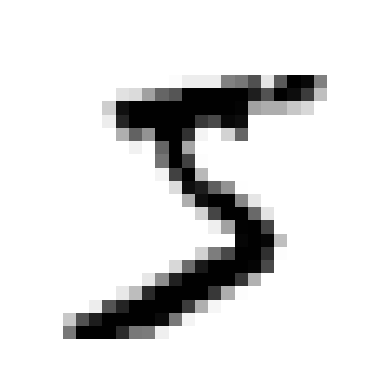

In [4]:
plt.imshow(X.iloc[0].to_numpy().reshape(28, 28), cmap = 'binary')
plt.axis('off')

In [5]:
y[0]

'5'

In [6]:
# The MNIST dataset is already split into a training set (the first 60,000 images) and a test set (the last 10,000 images). So we can just split it like this:
X_train = X.iloc[:60000]
X_test  = X.iloc[60000:]
y_train = y.iloc[:60000]
y_test  = y.iloc[60000:]

## 2. Training a Binary Classifier

Goal: distinguish two classes, 5 and non-5.

In [7]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

`SGDClassifier` is a linear model. It assigns a weight per class to each pixel, and sums up the weighted pixel intensities to get a score for each class.

In [8]:
sgd_clf = SGDClassifier(random_state=316)

sgd_clf.fit(X_train, y_train_5)
sgd_clf.predict(X_train.iloc[:5])

array([ True, False, False, False, False])

## 3. Performance Measures

### 3.1. Measuring Accuracy Using Cross-Validation

In [9]:
kf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 316)

In [10]:
cross_val_score(sgd_clf, X_train, y_train_5, cv = kf, scoring = 'accuracy')

array([0.94891667, 0.95775   , 0.96675   , 0.96475   , 0.96375   ])

In [11]:
dummy_clf = DummyClassifier(strategy = 'most_frequent')
cross_val_score(dummy_clf, X_train, y_train_5, cv = kf, scoring = 'accuracy')

array([0.90958333, 0.90966667, 0.90966667, 0.90966667, 0.90966667])

Above results demonstrate why accuracy is generally not the preferred performance measure for classifiers, especially when dealing with skewed datasets. **Confusion matrix (CM)** is a better approach to evaluate the performance of a classifier.

### 3.2. Confusion Matrices

This demonstrates why accuracy is generally not the preferred performance measure for classifiers, especially when you are dealing with skewed datasets (i.e., when some classes are much more frequent than others).

In [12]:
y_train_5_cv_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv = kf)

In [13]:
cm = confusion_matrix(y_train_5, y_train_5_cv_pred)
cm

array([[54051,   528],
       [ 1849,  3572]])

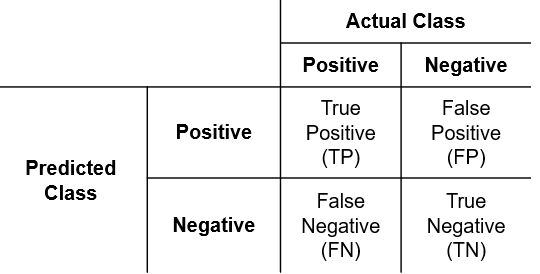
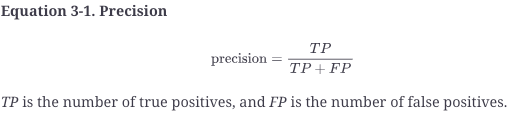
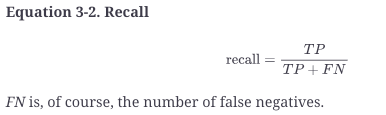
<br>

- ***Precision***: Among the samples I predicted as positive, how many are actually true? 
    - Aim of the metric: Reduce false positives, avoid mistaken classification
- ***Recall***: Among all the true positive samples, how many did I capture?
    - Aim of the metric: don't miss any positive instances.

### 3.3. Precision and Recall

It is often convenient to combine precision and recall into a single metric called the ***F1 score***, especially when you need a single metric to compare two classifiers. The F1 score is the **harmonic mean** of precision and recall (Equation 3-3). Whereas the regular mean treats all values equally, the harmonic mean gives much more weight to low values.
<br>

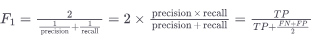
<br>
**The F1 score favors classifiers that have similar precision and recall**. This is not always what you want: in some contexts you mostly care about precision, and in other contexts you really care about recall.

In [14]:
print(f'The Precision is {precision_score(y_train_5, y_train_5_cv_pred)}')
print(f'The Recall is {recall_score(y_train_5, y_train_5_cv_pred)}')
print(f'The F1 score is {f1_score(y_train_5, y_train_5_cv_pred)}')

The Precision is 0.871219512195122
The Recall is 0.6589190186312488
The F1 score is 0.7503413506984561


### 3.4. The Precision/Recall Trade-Off

**The precision/recall trade-off**: Increasing precision reduces recall, and vice versa.
<br>
To understand this trade-off, let’s look at how the `SGDClassifier` makes its classification decisions. For each instance, it computes a score based on a decision function. If that score is greater than a threshold, it assigns the instance to the positive class; otherwise it assigns it to the negative class. 

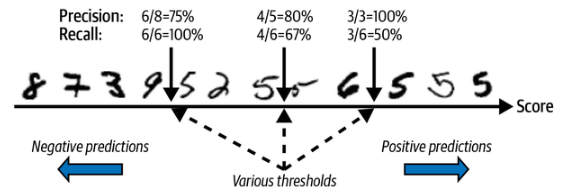

The `SGDClassifier` users a threshold equal to 0. 

In [15]:
y_score = sgd_clf.decision_function(X_train.iloc[[0]])
print(y_score)

[4342.30802343]


In [16]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv = kf, 
                             method = 'decision_function')

In [17]:
precision, recall, thresholds = precision_recall_curve(y_train_5, y_scores)
print(precision.shape)
print(recall.shape)
print(thresholds.shape)

(60001,)
(60001,)
(60000,)


The last precision and recall values are 1 and 0, respectively, and do not have a corresponding threshold. This ensures that the graph starts on the y axis. 

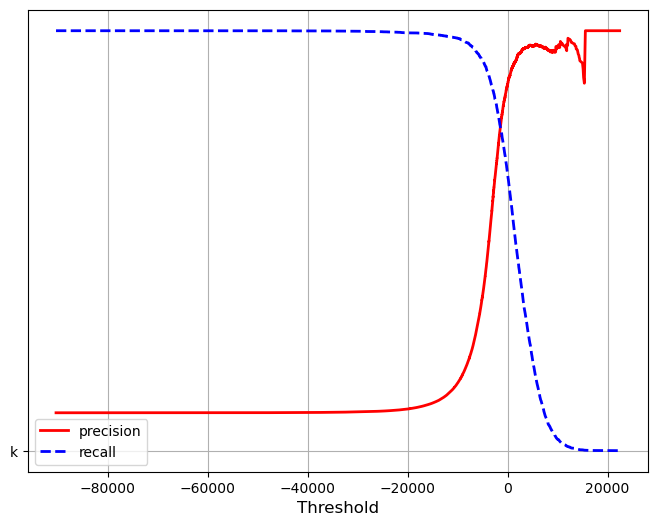

In [18]:
fig, ax = plt.subplots(figsize = (8,6))
ax.plot(thresholds, precision[:-1], 'r-', linewidth = 2, label = 'precision')
ax.plot(thresholds, recall[:-1], 'b--', linewidth = 2, label = 'recall')
ax.vlines(thresholds, 0, "k", linewidth = 4)
ax.set_xlabel('Threshold', fontsize = 12)
ax.legend()
ax.grid(True)
plt.show()

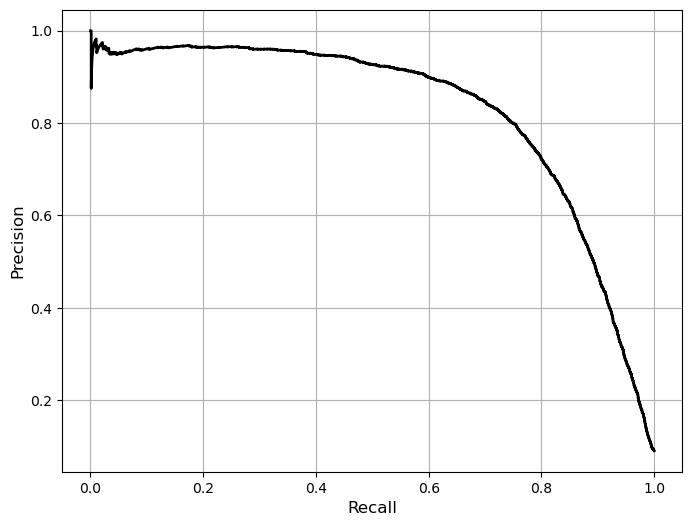

In [19]:
fig, ax = plt.subplots(figsize = (8,6))
ax.plot(recall[:-1], precision[:-1], 'k-', linewidth = 2)
ax.set_xlabel('Recall', fontsize = 12)
ax.set_ylabel('Precision', fontsize = 12)
ax.grid(True)
plt.show()

We can customized our threshoulds.

In [20]:
y_train_5_cv_pred_3000 = y_scores > 3000
print(f'Precision score is {precision_score(y_train_5, y_train_5_cv_pred_3000)}')
print(f'Recall score is {recall_score(y_train_5, y_train_5_cv_pred_3000)}')
print(f'F1 score is {f1_score(y_train_5, y_train_5_cv_pred_3000)}')

Precision score is 0.9553868058851448
Recall score is 0.37133370226895407
F1 score is 0.5348034006376196


### 3.5. The ROC Curve

The ROC curve plots the **recall** again **false positive rate** (i.e., **1 - specificity**)

In [21]:
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

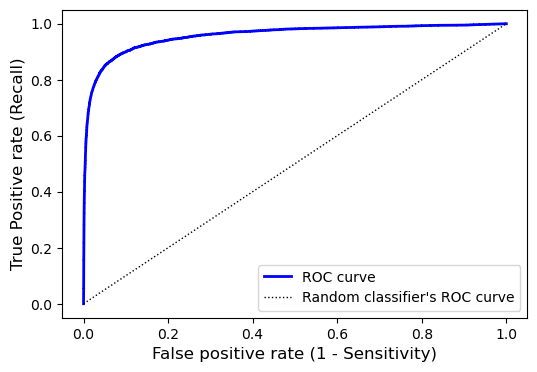

In [22]:
fig, ax = plt.subplots(figsize = (6, 4))
ax.plot(fpr, tpr, 'b-', linewidth = 2, label = 'ROC curve')
ax.plot([0,1], [0,1], 'k:', linewidth = 1, label = "Random classifier's ROC curve")
ax.set_xlabel("False positive rate (1 - Sensitivity)", fontsize = 12)
ax.set_ylabel("True Positive rate (Recall)", fontsize = 12)
ax.legend()
plt.show()

In [23]:
roc_auc_score(y_train_5, y_scores)

np.float64(0.9581488946740107)

As a rule of thumb, we prefer the precision/recall (PR) curve whenever the positive class is rare or when you care more about the false positives than the false negatives. Otherwise, use the ROC curve.

Let's try `RandomForestClassifier` and compare its performance with `SGDClassifier`

In [24]:
rf_clf = RandomForestClassifier(random_state=316)
y_scores_rf = cross_val_predict(rf_clf, X_train, y_train_5, cv = kf, method = 'predict_proba')

In [25]:
y_scores_rf[:2, ]

array([[0.12, 0.88],
       [0.99, 0.01]])

In [26]:
precision_rf, recall_rf, thresholds = precision_recall_curve(y_train_5, y_scores_rf[:, 1])

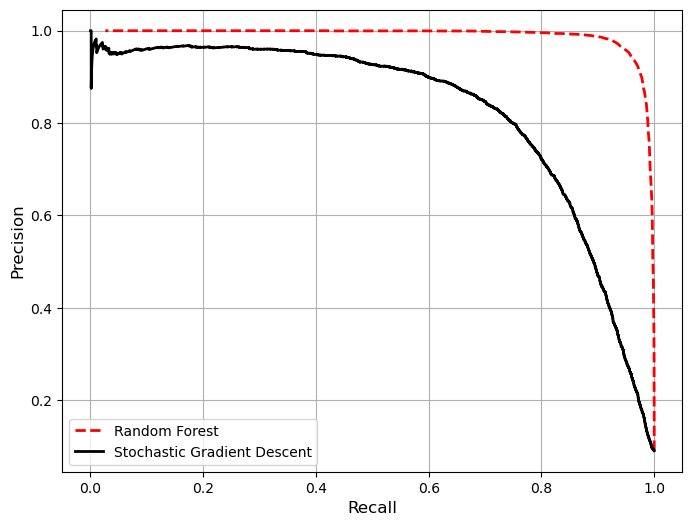

In [27]:
fig, ax = plt.subplots(figsize = (8, 6))
ax.plot(recall_rf[:-1], precision_rf[:-1], 'r--', linewidth = 2, label = "Random Forest")
ax.plot(recall[:-1], precision[:-1], 'k-', linewidth = 2, label = "Stochastic Gradient Descent")
ax.set_xlabel('Recall', fontsize = 12)
ax.set_ylabel('Precision', fontsize = 12)
ax.grid(True)
ax.legend()
plt.show()

In [28]:
y_train_5_cv_pred_rf = cross_val_predict(rf_clf, X_train, y_train_5, cv = kf)
print(f'Precision score is {precision_score(y_train_5, y_train_5_cv_pred_rf)}')
print(f'Recall score is {recall_score(y_train_5, y_train_5_cv_pred_rf)}')
print(f'F1 score is {f1_score(y_train_5, y_train_5_cv_pred_rf)}')

Precision score is 0.9908352426577797
Recall score is 0.8775133739162516
F1 score is 0.9307376247309724


## 4. Multiclass Classification

Some Scikit-Learn classifiers (e.g., `LogisticRegression`, `RandomForestClassifier`, and `GaussianNB`) are capable of handling multiple classes natively. Others are strictly binary classifiers (e.g., `SGDClassifier` and `SVC`). However, there are various strategies that you can use to perform multiclass classification with multiple binary classifiers.
- One way to create a system that can classify the digit images into 10 classes (from 0 to 9) is to train **N** (i.e., 10) binary classifiers, one for each digit (a 0-detector, a 1-detector, a 2-detector, and so on). Then when you want to classify an image, you get the decision score from each classifier for that image and you select the class whose classifier outputs the highest score. This is called the ***one-versus-the-rest (OvR)*** strategy, or sometimes ***one-versus-all (OvA)***.
- Another strategy is to train a binary classifier for every pair of digits: one to distinguish 0s and 1s, another to distinguish 0s and 2s, another for 1s and 2s, and so on. This is called the ***one-versus-one (OvO) strategy***. If there are N classes, you need to train **N × (N – 1) / 2** classifiers. For the MNIST problem, this means training 45 binary classifiers! When you want to classify an image, you have to run the image through all 45 classifiers and see which class wins the most duels. **The main advantage of OvO is that each classifier only needs to be trained on the part of the training set containing the two classes that it must distinguish**.
- Some algorithms (such as support vector machine classifiers) scale poorly with the size of the training set. For these algorithms OvO is preferred because it is faster to train many classifiers on small training sets than to train few classifiers on large training sets. 
- For most binary classification algorithms, however, OvR is preferred.




Scikit-Learn detects when you try to use a binary classification algorithm for a multiclass classification task, and it **automatically runs OvR or OvO, depending on the algorithm.**

In [29]:
svm_clf = SVC(random_state = 316)
svm_clf.fit(X_train.iloc[0:2000], y_train.iloc[0:2000]) 
# We’ll only train on the first 2,000 images, or else it will take a very long time

SVC(random_state=316)

In [30]:
svm_clf.predict(X_train.iloc[[0]])

array(['5'], dtype=object)

In [31]:
svm_clf.decision_function(X_train.iloc[[0]])

array([[ 3.79297828,  0.72949369,  6.06184129,  8.29800527, -0.29383983,
         9.30157597,  1.74723215,  2.77365456,  7.20601456,  4.82245092]])

When a classifier is trained, it stores the list of target classes in its `classes_` attribute, ordered by value.

In [32]:
svm_clf.classes_[svm_clf.decision_function(X_train.iloc[[0]]).argmax()]

'5'

We can force Scikit-Learn to use OVO or OVR by using the `OneVsOneClassifier` or `OneVsRestClassifier` classes. Simply create an instance and pass a classifier to its constructor.

In [33]:
svm_ovr_clf = OneVsRestClassifier(SVC(random_state=316))
svm_ovr_clf.fit(X_train.iloc[:2000], y_train.iloc[0:2000])

OneVsRestClassifier(estimator=SVC(random_state=316))

In [34]:
svm_ovr_clf.predict(X_train.iloc[[0]])

array(['5'], dtype='<U1')

In [35]:
sgd_ovo_clf = OneVsOneClassifier(SGDClassifier(random_state=316))
sgd_ovo_clf.fit(X_train.iloc[:2000], y_train.iloc[0:2000])

OneVsOneClassifier(estimator=SGDClassifier(random_state=316))

In [36]:
sgd_ovo_clf.predict(X_train.iloc[[0]])

array(['5'], dtype=object)

In [37]:
sgd_ovo_clf.decision_function(X_train.iloc[[0]])

array([[ 2.66666668,  4.66666669,  4.66666679,  8.33333333, -0.33333333,
         9.33333333,  1.66666667,  2.66666668,  7.33333332,  2.66666671]])

In [38]:
cross_val_score(sgd_ovo_clf, X_train.iloc[:2000], y_train.iloc[:2000], cv = kf, scoring='accuracy')

array([0.89  , 0.8875, 0.8825, 0.895 , 0.8825])

## 5. Error Analysis

To evaluate the performance for multiclass prediction and analyze the types of errors it makes, we can use a **colored diagram of the confusion matrix**. (Assume we have found a promising model).

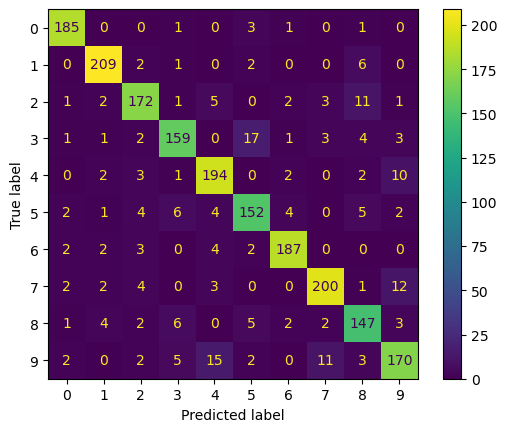

In [39]:
y_train_cv_pred = cross_val_predict(sgd_ovo_clf, X_train.iloc[:2000], y_train.iloc[:2000], cv = kf)
ConfusionMatrixDisplay.from_predictions(y_train.iloc[:2000], y_train_cv_pred)
plt.show()

We can normalize the confusion matrix by **row** (dividing each value by the **row**’s sum). Now, we can easily see that 9% of '3' was misclassified as '5', and 7% of '9' was misclassified as '4'. 

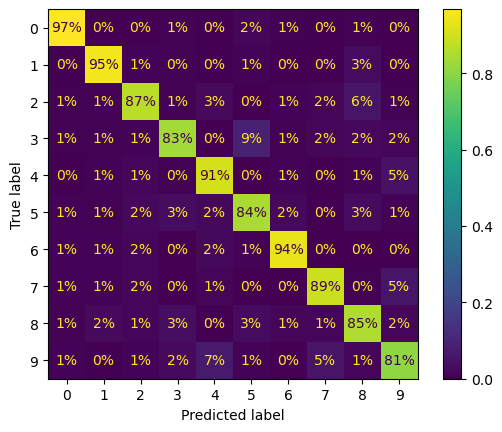

In [40]:
ConfusionMatrixDisplay.from_predictions(y_train.iloc[:2000], y_train_cv_pred, 
                                        normalize='true', values_format=".0%")
plt.show()

We can also normalize the confusion matrix by **column** by setting `normalize="pred"`, 

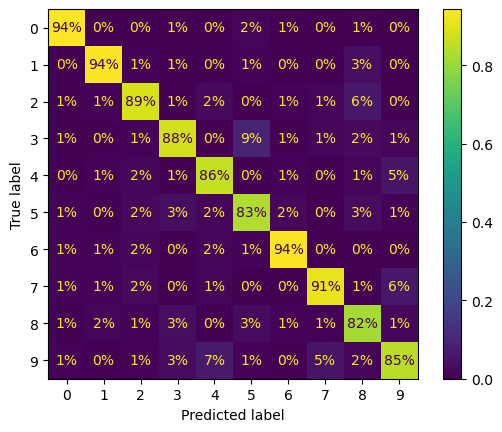

In [41]:
ConfusionMatrixDisplay.from_predictions(y_train.iloc[:2000], y_train_cv_pred, 
                                        normalize='pred', values_format=".0%")
plt.show()

We can make the errors stand out more by putting zero weight on the correct predictions (can either by row or column).

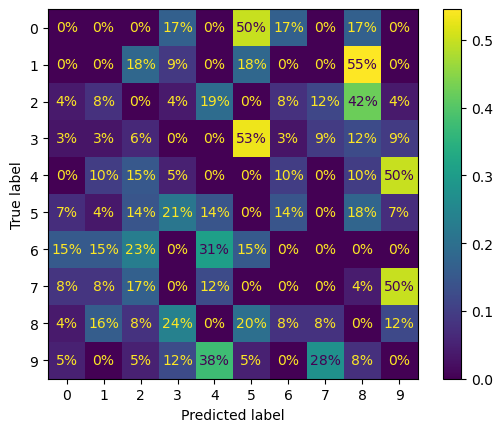

In [42]:
ConfusionMatrixDisplay.from_predictions(y_train.iloc[:2000], y_train_cv_pred, 
                                        normalize='true', values_format=".0%",
                                        sample_weight=(y_train_cv_pred != y_train.iloc[:2000]).astype(int))
plt.show()

Analyzing the confusion matrix often gives us insights into ways to improve our classifier. For example, we may spent time to distinguish 3 vs 5, and 7 vs 9 by gathering more data, engineer new features, or preprocess the images (to make some patterns stand out more).

## 6. Multilabel Classification

A classification system that outputs **multiple binary** tags is called a ***multilabel classification*** system. 
- For instance, a face-recognitiion classifier that recognizes several pople in the same picture. It should attach one tag per person it recognizes. Say the classifier has been trained to recognize three faces: Alice, Bob, and Charlie. Then when the classifier is shown a picture of Alice and Charlie, it should output [True, False, True] (meaning “Alice yes, Bob no, Charlie yes”).

In [53]:
y_train_large = (y_train.astype('int') >= 7)
y_train_odd = (y_train.astype('int') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)
knn_clf.predict(X_train.iloc[[0]])

array([[False,  True]])

One approach to evaluate a multilabel classifier is to measure the F1 score for each individual label and then simply compute the average score `average = 'macro'`, this approach assumes that all labels are equally important, which may not be the case.

In [68]:
kf_unstratified = KFold(n_splits=5, shuffle=True, random_state=316)

y_train_knn_pred = cross_val_predict(knn_clf, X_train.iloc[:2000], y_multilabel[:2000], cv = kf_unstratified)
f1_score(y_multilabel[:2000], y_train_knn_pred[:2000], average = 'macro')
# Note: Stratified sampling requires each sample to belong to a single class. 
# In multilabel settings, each sample has a combination of labels (e.g. [True, False]), 
# so there's no single "class" to stratify on.

0.9308048551265509

If we have many more pictures of Alice than of Bob or Charlie, we may want to give more weight to the classifier’s score on pictures of Alice. One simple option is to give each label a weight equal to its support (i.e., the number of instances with that target label) by specify `average = 'weighted'`.

In [69]:
f1_score(y_multilabel[:2000], y_train_knn_pred[:2000], average = 'weighted')

0.9333834774729531

If we wish to use a classifier that does not natively support multilabel classification, such as `SVC`, one possible strategy is to train one model per label. However, this strategy may have a hard time capturing the dependencies between the labels. For example, a large digit (7, 8, or 9) is twice more likely to be odd than even, but the classifier for the “odd” label does not know what the classifier for the “large” label predicted. To solve this issue, the models can be organized in a chain: when a model makes a prediction, it uses the input features plus all the predictions of the models that come before it in the chain. `ClassifierChain` does just it. Note that the order of the classifiers in the chain may affect the final performance.

In [73]:
svc_chain_clf = ClassifierChain(SVC(), cv=kf_unstratified, order='random', random_state=316)
svc_chain_clf.fit(X_train.iloc[1:2000], y_multilabel[1:2000])
svc_chain_clf.predict(X_train.iloc[[0]])

array([[0., 1.]])

In [77]:
svc_chain_clf.order_ # predict (is_large) first, then (is_odd)

array([0, 1])

## 7. Multioutput Classification